# xrt_toolkit tutorial — 3D

Same operators as the 2D tutorial, in three dimensions: a parallel (cylinder)
scan reconstructed with `fbp` and `bpf`, and a cone-beam scan reconstructed
with FDK and with backprojection-then-filtering (`fbp_cone`,
`method="fdk" | "bpf"`). A CUDA GPU is required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
from drjit.cuda.ad import Float

import xrt_toolkit as xtk

# problem size: change these to explore other configurations
N = 96             # volume is N^3
N_angles = 180     # parallel scan; the cone scan uses 2x over a full circle
N_detectors = 144  # in-plane detector cells
order = 0          # basis: 0 voxels, 1 / 2 box splines (3D splines are slower)

# phantom: a large sphere with two inserts
zz, yy, xx = np.mgrid[:N, :N, :N].astype(np.float32)
vol = (((xx - N/2)**2 + (yy - N/2)**2 + (zz - N/2)**2) < (0.32*N)**2).astype(np.float32)
vol += 0.6 * (((xx - 0.64*N)**2 + (yy - 0.42*N)**2 + (zz - 0.5*N)**2) < (0.09*N)**2)
vol -= 0.4 * (((xx - 0.4*N)**2 + (yy - 0.58*N)**2 + (zz - 0.38*N)**2) < (0.09*N)**2)
f = Float(vol.reshape(-1))

knot = xtk.UniformSpec(start=(-N/2 + 0.5,) * 3, step=1, num=(N,) * 3)


def show_slices(recs, titles):
    fig, axs = plt.subplots(2, len(recs), figsize=(3.2*len(recs), 6.2), squeeze=False)
    for j, (r, ti) in enumerate(zip(recs, titles)):
        r = np.asarray(r).reshape(N, N, N)
        axs[0][j].imshow(r[N//2], cmap="gray", vmin=-0.1, vmax=1.7)
        axs[0][j].set_title(ti)
        axs[1][j].imshow(r[:, :, N//2], cmap="gray", vmin=-0.1, vmax=1.7)
    axs[0][0].set_ylabel("axial"); axs[1][0].set_ylabel("coronal")
    for row in axs:
        for ax in row:
            ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()

## Parallel (cylinder) scan

A 2D `DetectorSpec` turns `parallel_beam` into a 3D scan. `fbp` ramp-filters
along the in-plane detector axis; `bpf` backprojects first and deconvolves the
in-plane blur in the volume.

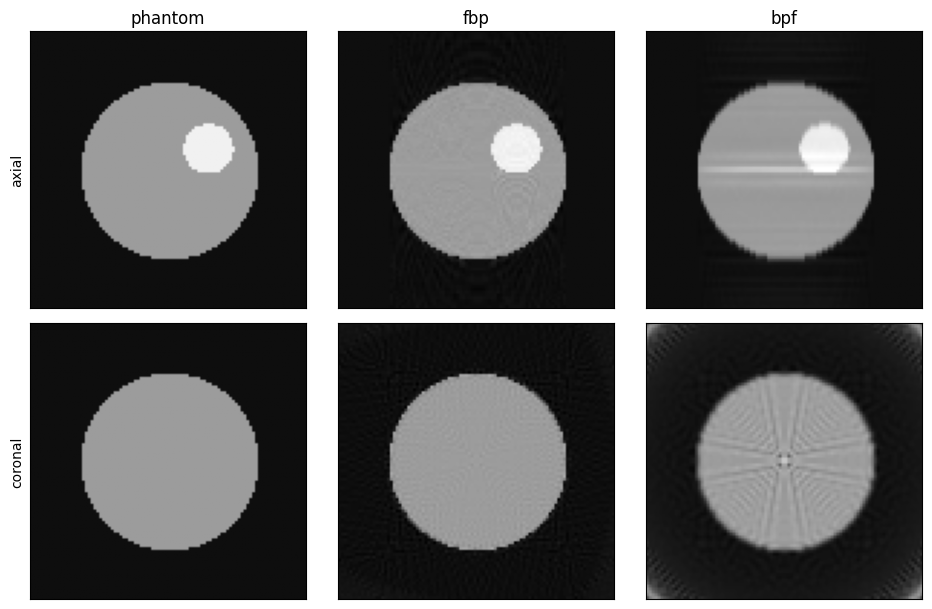

In [2]:
det = xtk.DetectorSpec(size=(1.5*N, 1.5*N), num_cell=(N_detectors, N_detectors))
rays_par = xtk.parallel_beam(dr.linspace(Float, 0, np.pi, N_angles, endpoint=False), det)
y_par = xtk.xrt_apply(xtk.struct_rays(rays_par), knot, order, f)

rec_fbp = xtk.fbp(rays_par, knot, y_par, order=order, window="ramp")
rec_bpf = xtk.bpf(rays_par, knot, y_par, order=order)
show_slices([f, rec_fbp, rec_bpf], ["phantom", "fbp", "bpf"])

## Cone-beam scan

`fbp_cone` reconstructs a full-circle cone scan with FDK (cosine
pre-weighting + ramp filtering along the in-plane axis + backprojection;
exact in the midplane). Backprojection-then-filtering is a parallel-scan
method — the divergent backprojection blur is not shift-invariant, so
`method="bpf"` raises for cone scans; use FDK or `cg`.

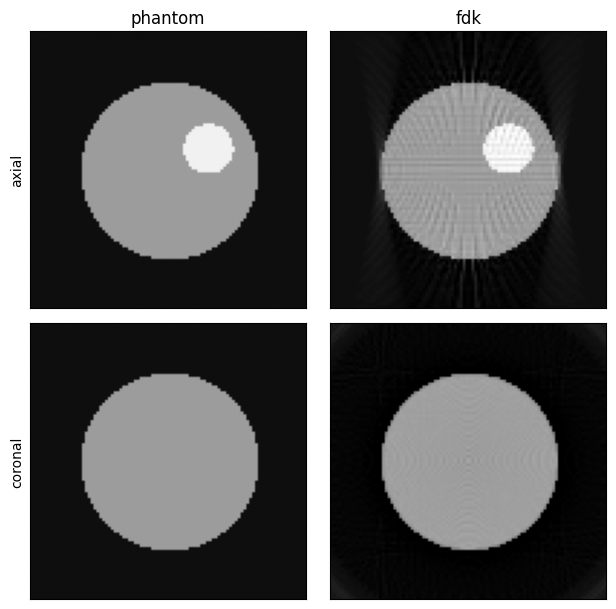

In [3]:
sod, sdd = 1.6 * N, 2.8 * N
det_cb = xtk.DetectorSpec(size=(2.2*N, 1.75*N), num_cell=(N_detectors + 48, N_detectors))
rays_cone = xtk.cone_beam(sod=sod, sdd=sdd,
                          angles=dr.linspace(Float, 0, 2*np.pi, 2*N_angles, endpoint=False),
                          detector_spec=det_cb)
y_cone = xtk.xrt_apply(xtk.struct_rays(rays_cone), knot, order, f)

rec_fdk = xtk.fbp_cone(rays_cone, knot, y_cone, sod=sod, sdd=sdd,
                       order=order, window="ramp")
show_slices([f, rec_fdk], ["phantom", "fdk"])

## Iterative reconstruction

`cg` works unchanged in 3D — the operators do not care about the dimension.
On noiseless data it converges toward the exact discrete solution; with noise
it must be stopped early (see the 2D tutorial).

PSNR  fbp 35.7  bpf 26.5  fdk 30.2  cg 36.8 dB


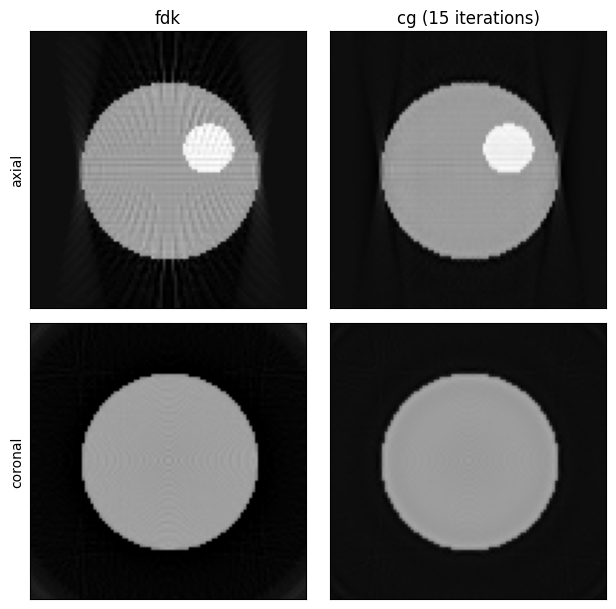

In [4]:
re = xtk.struct_rays(rays_cone)
rec_cg = xtk.cg(lambda v: xtk.xrt_apply(re, knot, order, v),
                lambda v: xtk.xrt_adjoint(re, knot, order, v), y_cone, N**3, n_iter=15)
show_slices([rec_fdk, rec_cg], ["fdk", "cg (15 iterations)"])

def psnr(r):
    r = np.asarray(r).reshape(N, N, N)
    return 10 * np.log10(vol.max()**2 / np.mean((r - vol)**2))
print(f"PSNR  fbp {psnr(rec_fbp):.1f}  bpf {psnr(rec_bpf):.1f}  "
      f"fdk {psnr(rec_fdk):.1f}  cg {psnr(rec_cg):.1f} dB")